In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [14]:
df = pd.read_csv("../data/processed/movies_enriched.csv")

df.head()

,userId,movieId,rating,timestamp,title,genres,rating_date,rating_year,rating_month,release_year,avg_rating,num_ratings,rating_std,avg_rating_given,num_movies_rated,favorite_genre
0,1,1,4.0,964982703,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,2000-07-30 18:45:03,2000,7,1995.0,3.920930,215,0.834859,4.366379,232,Action
1,1,3,4.0,964981247,Grumpier Old Men,Comedy|Romance,2000-07-30 18:20:47,2000,7,1995.0,3.259615,52,1.054823,4.366379,232,Action
2,1,6,4.0,964982224,Heat,Action|Crime|Thriller,2000-07-30 18:37:04,2000,7,1995.0,3.946078,102,0.817224,4.366379,232,Action
3,1,47,5.0,964983815,Seven (a.k.a. Se7en),Mystery|Thriller,2000-07-30 19:03:35,2000,7,1995.0,3.975369,203,0.922429,4.366379,232,Action
4,1,50,5.0,964982931,"Usual Suspects, The",Crime|Mystery|Thriller,2000-07-30 18:48:51,2000,7,1995.0,4.237745,204,0.800921,4.366379,232,Action


In [15]:
import os

os.makedirs("../images", exist_ok=True)

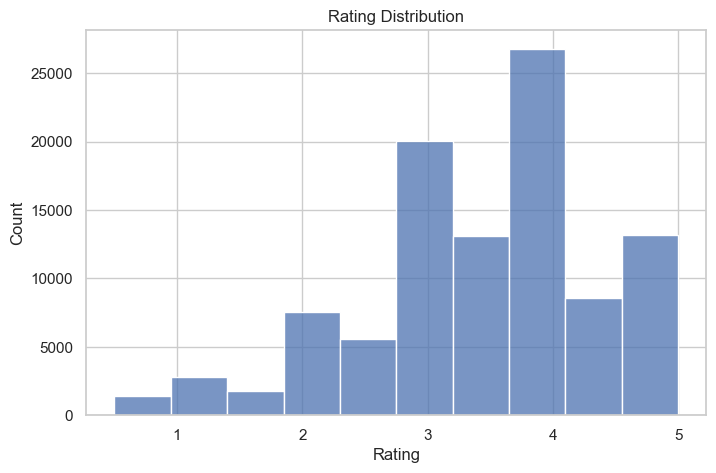

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(df["rating"], bins=10)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.savefig("../images/01_rating_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

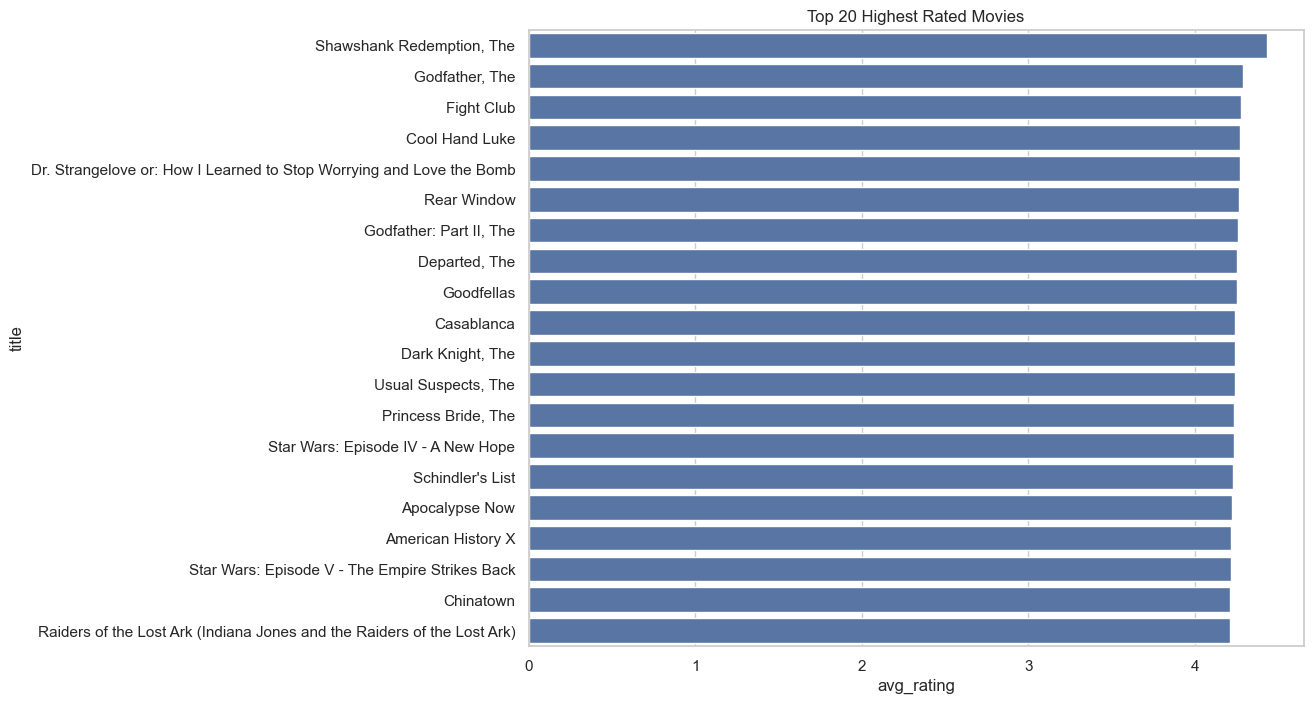

In [17]:
top_movies = (
    df[df["num_ratings"] >= 50]
    .groupby("title")
    .agg(
        avg_rating=("rating","mean"),
        num_ratings=("rating","count")
    )
    .sort_values("avg_rating",ascending=False)
    .head(20)
)

plt.figure(figsize=(10,8))

sns.barplot(
    x="avg_rating",
    y=top_movies.index,
    data=top_movies
)

plt.title("Top 20 Highest Rated Movies")

plt.savefig("../images/02_top_rated_movies.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

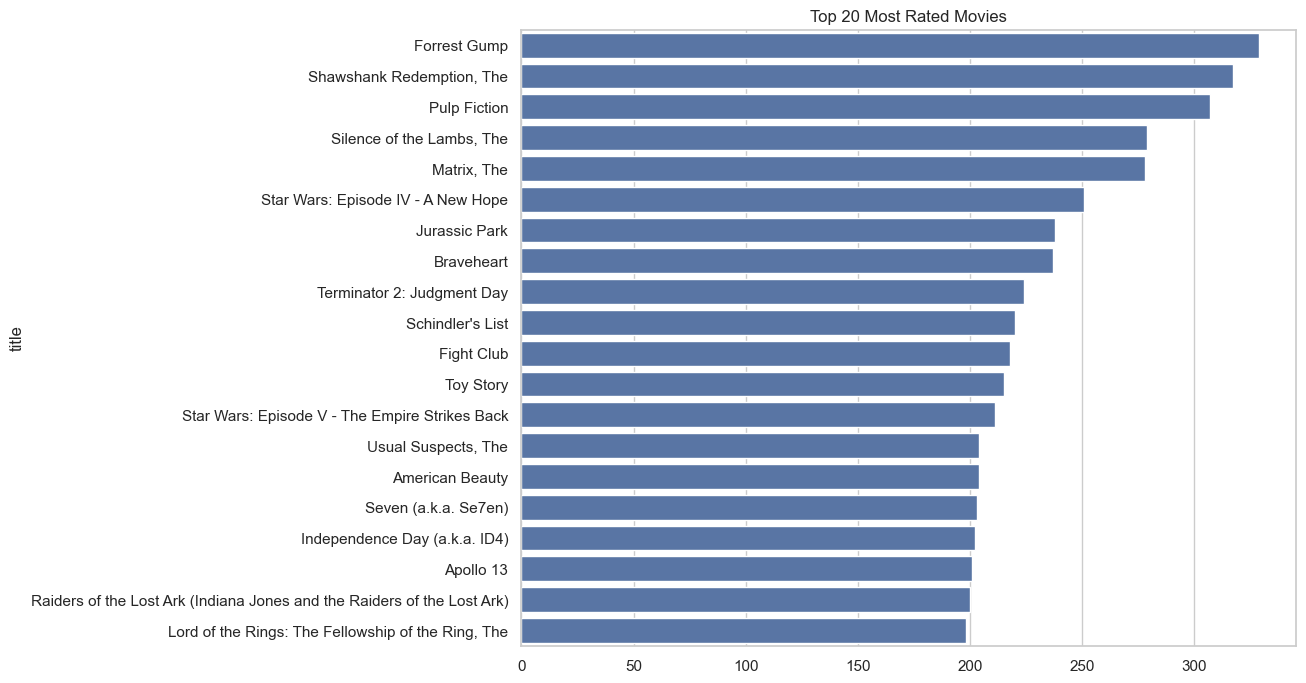

In [18]:
popular = (
    df.groupby("title")
    .size()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(10,8))

sns.barplot(
    x=popular.values,
    y=popular.index
)

plt.title("Top 20 Most Rated Movies")

plt.savefig("../images/03_most_rated_movies.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

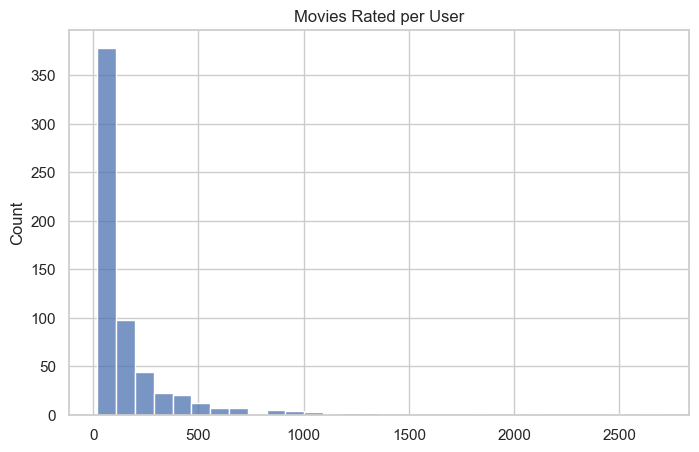

In [19]:
user_activity = (
    df.groupby("userId")
    .size()
)

plt.figure(figsize=(8,5))

sns.histplot(
    user_activity,
    bins=30
)

plt.title("Movies Rated per User")

plt.savefig("../images/04_user_activity.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

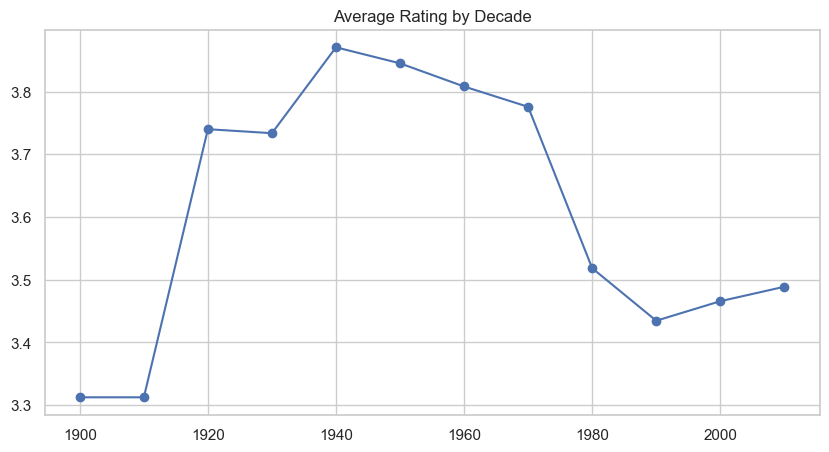

In [20]:
df["decade"] = (
    df["release_year"]//10
)*10

decade = (
    df.groupby("decade")
    .agg(avg_rating=("rating","mean"))
)

plt.figure(figsize=(10,5))

plt.plot(
    decade.index,
    decade["avg_rating"],
    marker="o"
)

plt.title("Average Rating by Decade")

plt.savefig("../images/05_rating_by_decade.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

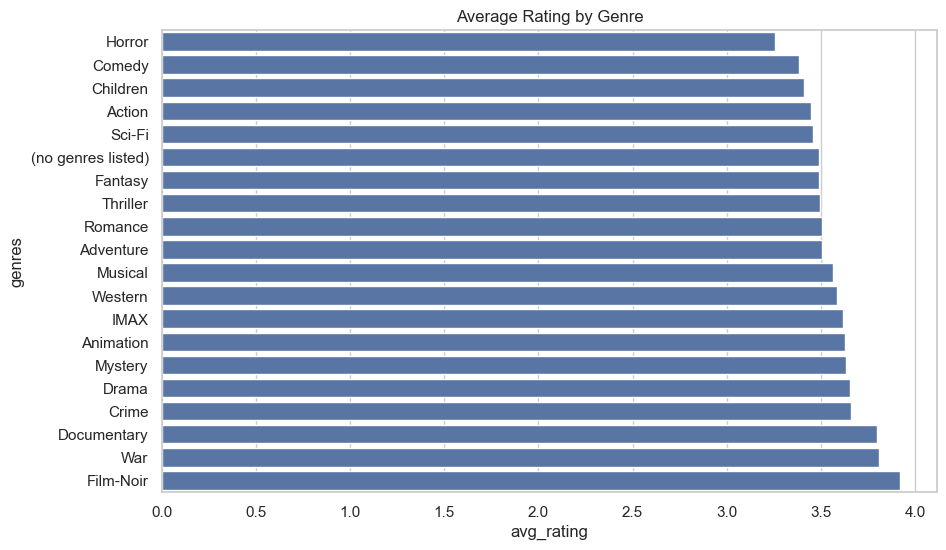

In [21]:
genre_df = df.copy()

genre_df["genres"] = genre_df["genres"].str.split("|")

genre_df = genre_df.explode("genres")

genre_rating = (
    genre_df.groupby("genres")
    .agg(avg_rating=("rating","mean"))
    .sort_values("avg_rating")
)

plt.figure(figsize=(10,6))

sns.barplot(
    x="avg_rating",
    y=genre_rating.index,
    data=genre_rating
)

plt.title("Average Rating by Genre")

plt.savefig("../images/06_genre_rating.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

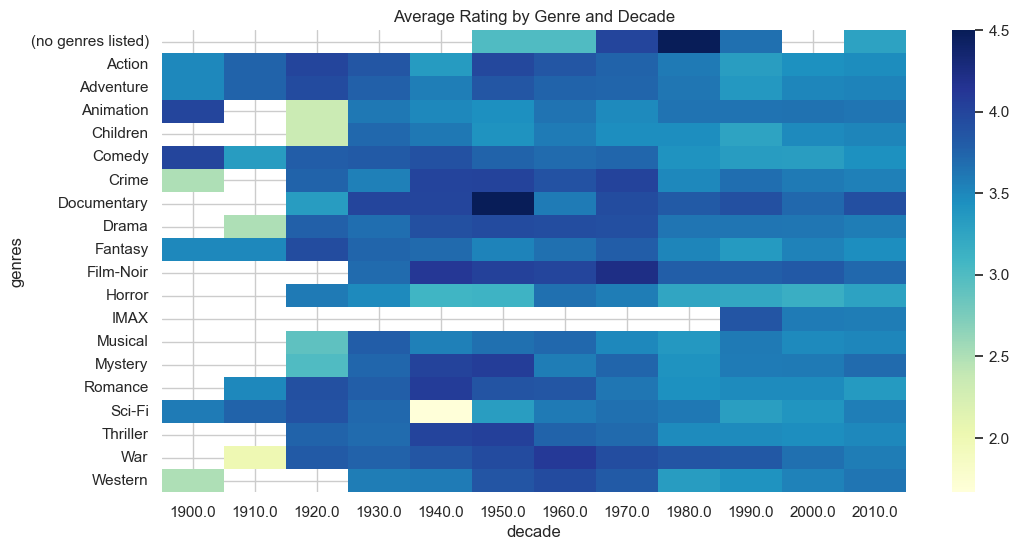

In [22]:
heatmap = (
    genre_df.groupby(["genres","decade"])
    .agg(avg_rating=("rating","mean"))
    .reset_index()
)

pivot = heatmap.pivot(
    index="genres",
    columns="decade",
    values="avg_rating"
)

plt.figure(figsize=(12,6))

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.title("Average Rating by Genre and Decade")

plt.savefig("../images/07_heatmap.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

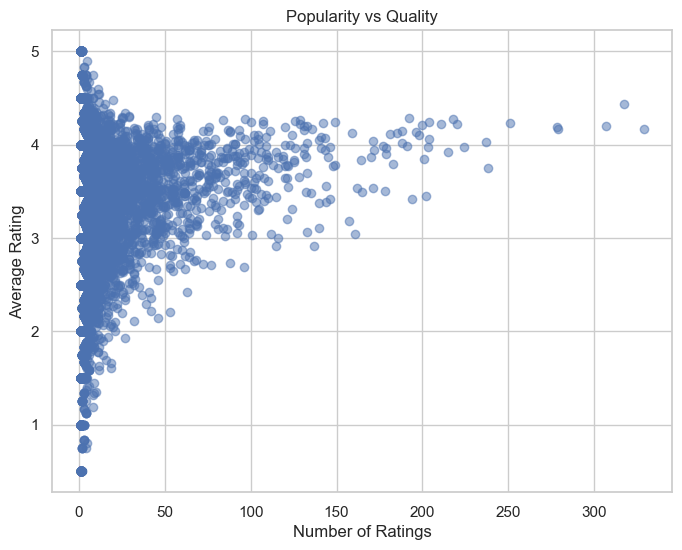

In [23]:
movie_summary = (
    df.groupby("title")
    .agg(
        avg_rating=("rating","mean"),
        num_ratings=("rating","count")
    )
)

plt.figure(figsize=(8,6))

plt.scatter(
    movie_summary["num_ratings"],
    movie_summary["avg_rating"],
    alpha=0.5
)

plt.xlabel("Number of Ratings")
plt.ylabel("Average Rating")

plt.title("Popularity vs Quality")

plt.savefig("../images/08_popularity_vs_quality.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [24]:
print("Week 3 Completed Successfully!")

Week 3 Completed Successfully!
